In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np

In [ ]:
!pip install geopandas
!pip install pykrige

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
import tensorflow as tf
from keras import layers, models
from sklearn.pipeline import Pipeline
import pykrige #biblioteca de geoestadística
import pykrige.kriging_tools as kt #herramientas para exportar e importar archivos .asc con biblioteca PyKrige
from pykrige.ok import OrdinaryKriging #Kriging Ordinario con PyKrige

forecasting

In [ ]:
path="/content/drive/MyDrive/investigacion/3ddespues/PRUEBA"
df=pd.read_csv(path+"/dataset2003-01-01.csv")
df.head()

,lat,lon,band1,band2,band3,band4,band5,band6,band7,irradiance
0,-8789850.0,184950.0,0.101755,0.078818,0.051683,0.264549,0.129877,296.541341,0.043120,204.986188
1,-8784900.0,174600.0,0.103636,0.081440,0.051834,0.276332,0.131768,296.468388,0.043376,202.845077
2,-8775000.0,164700.0,0.106230,0.095642,0.069535,0.328565,0.178510,295.296542,0.075029,208.215425
3,-8775000.0,169650.0,0.106100,0.085670,0.058951,0.267595,0.123353,294.432919,0.046396,200.875290
4,-8775000.0,174600.0,0.105858,0.082105,0.051419,0.279088,0.128134,296.558853,0.040179,200.495335


In [ ]:
min_lat=df["lat"].min()
max_lat=df["lat"].max()
min_lon=df["lon"].min()
max_lon=df["lon"].max()
print(min_lat,max_lat,min_lon,max_lon)

-8789850.0 -8554950.0 45000.0 294750.0


In [ ]:
lat=df['lat'].unique()
lon=df['lon'].unique()

lat=np.sort(lat)
lon=np.sort(lon)
dif_lat=np.diff(lat)
dif_lon=np.diff(lon)

min_dif_lat=np.min(dif_lat)
min_dif_lon=np.min(dif_lon)

print(min_dif_lat,min_dif_lon)

4950.0 4950.0


In [ ]:

def get_images(df,max_lat,min_lat,max_lon,min_lon):
  rows = int(np.ceil((max_lat - min_lat) / 4950)) + 1
  cols = int(np.ceil((max_lon - min_lon) / 4950)) + 1
  matrix_b1 = np.zeros((cols, rows))
  matrix_b2 = np.zeros((cols, rows))
  matrix_b3 = np.zeros((cols, rows))
  matrix_b4 = np.zeros((cols, rows))
  matrix_b5 = np.zeros((cols, rows))
  matrix_b6 = np.zeros((cols, rows))
  matrix_b7 = np.zeros((cols, rows))
  matrix_b8 = np.zeros((cols, rows))
  matrix_irradiance = np.zeros((cols, rows))

  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_lat) / 4950))
      lon_index = int(np.floor((max_lon-row['lon']) / 4950))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        matrix_b1[lon_index, lat_index] = row['band1']
        matrix_b2[lon_index, lat_index] = row['band2']
        matrix_b3[lon_index, lat_index] = row['band3']
        matrix_b4[lon_index, lat_index] = row['band4']
        matrix_b5[lon_index, lat_index] = row['band5']
        matrix_b6[lon_index, lat_index] = row['band6']
        matrix_b7[lon_index, lat_index] = row['band7']
        matrix_b8[lon_index, lat_index] = row['irradiance']

        matrix_irradiance[lon_index, lat_index] = row['irradiance']

  satelital_image = np.stack((matrix_b1, matrix_b2, matrix_b3, matrix_b4, matrix_b5, matrix_b6, matrix_b7,matrix_b8), axis=-1)
  return satelital_image,matrix_irradiance

def get_dataframe(df,matrix,max_lat,min_lat,max_lon,min_lon):
  rows = int(np.ceil((max_lat - min_lat) / 4950)) + 1
  cols = int(np.ceil((max_lon - min_lon) / 4950)) + 1
  lat=[]
  lon=[]
  irradiance=[]
  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_lat) / 4950))
      lon_index = int(np.floor((max_lon-row['lon']) / 4950))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        lat.append(row['lat'])
        lon.append(row['lon'])
        irradiance.append(matrix[lon_index, lat_index])

  df_result=pd.DataFrame({'latitude':lat,'longitude':lon,'irradiance':irradiance})
  return df_result

In [ ]:
satelital_image,matrix_irradiance=get_images(df,max_lat,min_lat,max_lon,min_lon)
satelital_image.shape,matrix_irradiance.shape

((52, 49, 8), (52, 49))

aqui

In [ ]:
#nombre dce columnas
print(df.columns)

Index(['lat', 'lon', 'band1', 'band2', 'band3', 'band4', 'band5', 'band6',
       'band7', 'irradiance'],
      dtype='object')


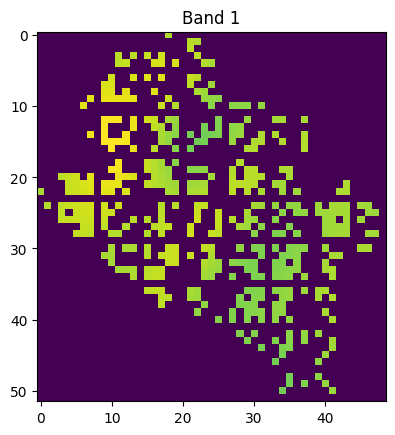

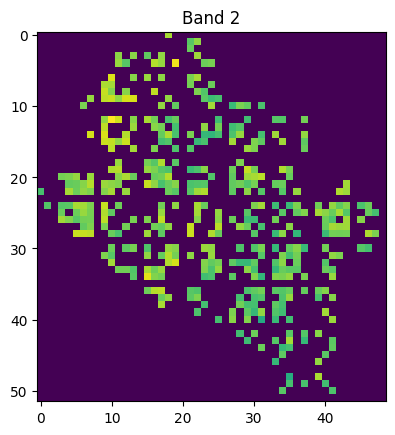

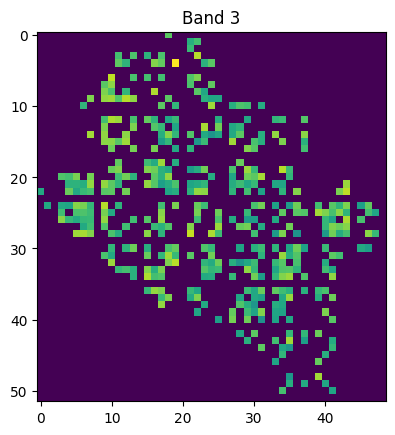

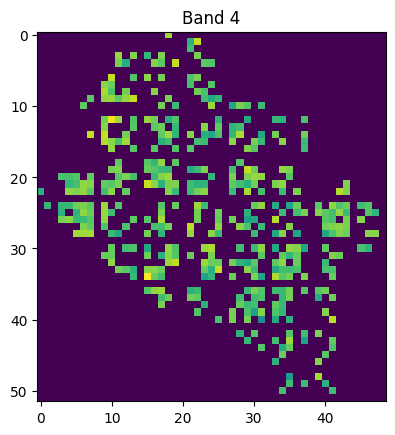

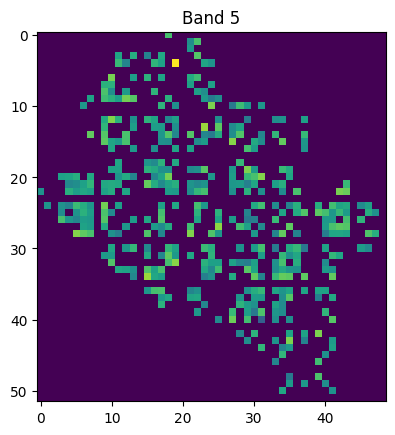

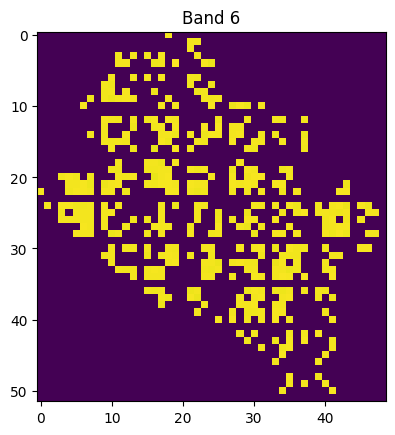

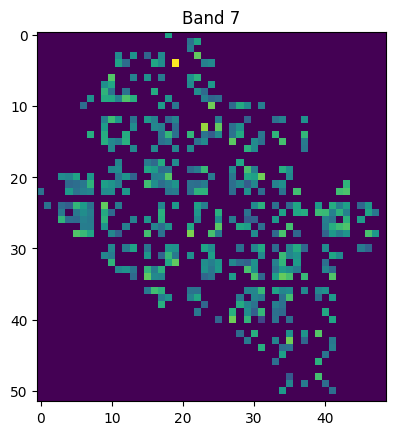

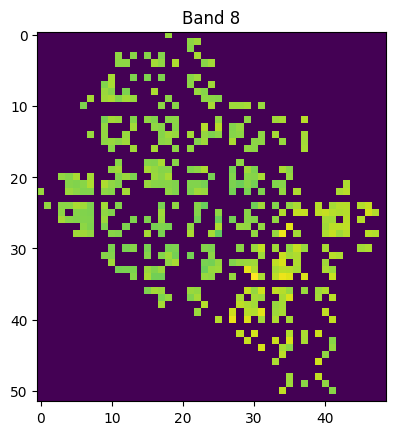

In [ ]:
for i in range(satelital_image.shape[2]):
  plt.title(f"Band {i+1}")
  plt.imshow(satelital_image[:,:,i])
  plt.show()

In [ ]:
satelital_image,matrix_irradiance=get_images(df,max_lat,min_lat,max_lon,min_lon)
satelital_image.shape,matrix_irradiance.shape

((52, 49, 8), (52, 49))

In [ ]:
##original
X=[]
y=[]
dates=[]
for filename in os.listdir(path):
  print(filename)
  if filename.endswith(".csv"):
    print("read file")
    df=pd.read_csv(path+"/"+filename)
    dates.append(filename.split(".")[0])
    print("get images 2 dataframe")
    satelital_image,matrix_irradiance=get_images(df,max_lat,min_lat,max_lon,min_lon)
    print("append images")
    X.append(satelital_image)
    y.append(matrix_irradiance)


Se truncaron las últimas líneas 5000 del resultado de transmisión.
read file
get images 2 dataframe
append images
dataset2008-07-15.csv
read file
get images 2 dataframe
append images
dataset2008-07-18.csv
read file
get images 2 dataframe
append images
dataset2008-07-21.csv
read file
get images 2 dataframe
append images
dataset2008-07-24.csv
read file
get images 2 dataframe
append images
dataset2008-07-27.csv
read file
get images 2 dataframe
append images
dataset2008-07-30.csv
read file
get images 2 dataframe
append images
dataset2008-08-02.csv
read file
get images 2 dataframe
append images
dataset2008-08-05.csv
read file
get images 2 dataframe
append images
dataset2008-08-08.csv
read file
get images 2 dataframe
append images
dataset2008-08-11.csv
read file
get images 2 dataframe
append images
dataset2008-08-14.csv
read file
get images 2 dataframe
append images
dataset2008-08-17.csv
read file
get images 2 dataframe
append images
dataset2008-08-20.csv
read file
get images 2 dataframe
app

In [ ]:
df

,lat,lon,band1,band2,band3,band4,band5,band6,band7,irradiance
0,-8789850.0,184950.0,0.102325,0.079569,0.05199,0.268903,0.122978,295.799095,0.043425,204.451064
1,-8784900.0,174600.0,0.102325,0.079569,0.05199,0.268903,0.122978,295.799100,0.043425,202.684906
2,-8775000.0,164700.0,0.102325,0.079569,0.05199,0.268903,0.122978,295.799101,0.043425,199.904829
3,-8775000.0,169650.0,0.102325,0.079569,0.05199,0.268903,0.122978,295.799103,0.043425,200.289535
4,-8775000.0,174600.0,0.102325,0.079569,0.05199,0.268903,0.122978,295.799104,0.043425,200.693742
...,...,...,...,...,...,...,...,...,...,...
429,-8559900.0,154800.0,0.102325,0.079569,0.05199,0.268903,0.122978,295.799102,0.043425,211.393688
430,-8559900.0,169650.0,0.102325,0.079569,0.05199,0.268903,0.122978,295.799104,0.043425,212.644234
431,-8559900.0,174600.0,0.102325,0.079569,0.05199,0.268903,0.122978,295.799104,0.043425,213.129333
432,-8554950.0,154800.0,0.102325,0.079569,0.05199,0.268903,0.122978,295.799098,0.043425,211.635192


In [ ]:
new_dates = []
for date in dates:
  new_dates.append(date.replace("dataset","").replace("landsat", ""))

In [ ]:
#convert str to date
from datetime import datetime
new_dates = [datetime.strptime(date, '%Y-%m-%d') for date in new_dates]

In [ ]:
X=np.array(X)

In [ ]:
y=np.array(y)

In [ ]:
X.shape,y.shape

((1461, 52, 49, 8), (1461, 52, 49))

In [ ]:
new_dates=np.array(new_dates)
index=np.argsort(new_dates)
X=X[index]
y=y[index]

In [ ]:
#min max scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X.reshape(-1, X.shape[-1])).reshape(X.shape)
X.shape

(1461, 52, 49, 8)

In [ ]:
y=scaler.fit_transform(y.reshape(-1, 1)).reshape(y.shape)
y.shape

(1461, 52, 49)

In [ ]:
X.min(),X.max(),y.min(),y.max()

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

aqui

windows


In [ ]:
#forecasting window
def window(X,y,v):
  yt=y[v:]
  Xt=[]
  for i in range(X.shape[0]-v):
    Xt.append(X[i:i+v])

  return np.array(Xt),yt

In [ ]:
Xt,yt=window(X,y,15)
Xt.shape,yt.shape

((1446, 15, 52, 49, 8), (1446, 52, 49))

In [ ]:
Xt.shape[1:]

(15, 52, 49, 8)

In [ ]:
Xt.shape

(1446, 15, 52, 49, 8)

In [ ]:
Xtrain=Xt[:int(0.8*Xt.shape[0])]
ytrain=yt[:int(0.8*yt.shape[0])]

Xtest=Xt[int(0.8*Xt.shape[0]):]
ytest=yt[int(0.8*yt.shape[0]):]

In [ ]:
X_train=Xtrain[:int(0.8*Xtrain.shape[0])]
y_train=ytrain[:int(0.8*ytrain.shape[0])]

X_test=Xtrain[int(0.8*Xtrain.shape[0]):]
y_test=ytrain[int(0.8*ytrain.shape[0]):]

model

aqui

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, ConvLSTM2D, Conv2D, BatchNormalization, Dropout

inputs = Input(shape=(Xt.shape[1:]))  # ventana temporal, alto, ancho, canales

x = ConvLSTM2D(filters=32, kernel_size=(3, 3), padding='same', return_sequences=False, activation='relu')(inputs)
x = BatchNormalization()(x)             # Normalización para estabilizar
x = Dropout(0.3)(x)                     # Dropout para evitar sobreajuste

x = Conv2D(filters=16, kernel_size=(3, 3), padding='same', activation='relu')(x)
x = BatchNormalization()(x)             # Otra capa de normalización
x = Dropout(0.3)(x)                     # Más dropout

outputs = Conv2D(filters=1, kernel_size=(3, 3), padding='same', activation='linear')(x)

model = Model(inputs, outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 15, 52, 49, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d (ConvLSTM2D)        │ (None, 52, 49, 32)     │        46,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 52, 49, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 52, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 52, 49, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 52, 49, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 52, 49, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 52, 49, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51,169 (199.88 KB)

 Trainable params: 51,073 (199.50 KB)

 Non-trainable params: 96 (384.00 B)

In [ ]:
path="/content/drive/MyDrive/investigacion/windows"


In [ ]:
#early stopping
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
#metrics
from tensorflow.keras.metrics import MeanAbsoluteError

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=10, min_lr=1e-8)
checkpoint= ModelCheckpoint(filepath=path+'model.keras', monitor='val_loss', save_best_only=True)

model.fit(Xtrain, ytrain, epochs=1000, batch_size=32,validation_data=(X_test,y_test), callbacks=[early_stopping, reduce_lr,checkpoint])

Epoch 1/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 24s 411ms/step - loss: 1.5687 - mae: 0.9178 - val_loss: 0.0537 - val_mae: 0.1643 - learning_rate: 0.0010
Epoch 2/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 204ms/step - loss: 0.5307 - mae: 0.5419 - val_loss: 0.0410 - val_mae: 0.1615 - learning_rate: 0.0010
Epoch 3/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 206ms/step - loss: 0.3233 - mae: 0.4290 - val_loss: 0.0441 - val_mae: 0.1531 - learning_rate: 0.0010
Epoch 4/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 205ms/step - loss: 0.2055 - mae: 0.3460 - val_loss: 0.0453 - val_mae: 0.1425 - learning_rate: 0.0010
Epoch 5/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step - loss: 0.1305 - mae: 0.2775 - val_loss: 0.0473 - val_mae: 0.1333 - learning_rate: 0.0010
Epoch 6/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 215ms/step - loss: 0.0830 - mae: 0.2222 - val_loss: 0.0468 - val_mae: 0.1246 - learning_rate: 0.0010
Epoch 7/1000
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 211ms/step - loss: 0.0525 - mae: 0.1768 - val_loss: 0.0423 - val_mae: 0.1197 - learning_rate

aqui

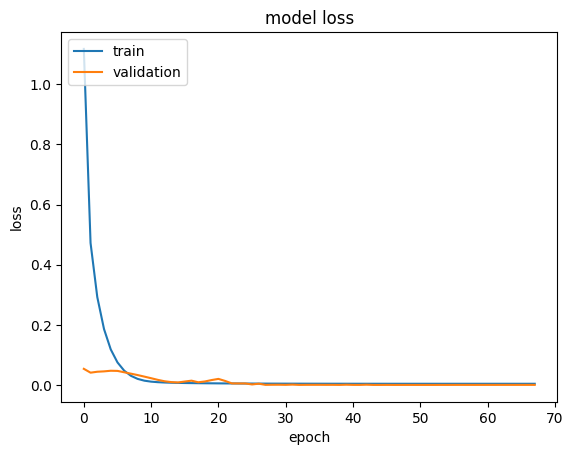

In [ ]:
#plot history
import matplotlib.pyplot as plt
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')


In [ ]:
model.evaluate(Xtest,ytest)

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 128ms/step - loss: 2.0481e-04 - mae: 0.0099


[0.00021064413886051625, 0.009987705387175083]

In [ ]:
ytest.shape

(290, 52, 49)

In [ ]:
#r2 score
from sklearn.metrics import r2_score
n=ytest.shape[0]
y_pred = model.predict(Xtest)
y_pred[ytest==0]=0
r2_score(ytest.reshape(n,-1), y_pred.reshape(n,-1))

from sklearn.metrics import r2_score

y_pred = model.predict(Xtest)
y_pred_squeezed = y_pred.squeeze() # Remove the last dimension of size 1
y_pred_squeezed[ytest==0]=0 # Apply the mask
r2_score(ytest.reshape(ytest.shape[0], -1), y_pred_squeezed.reshape(y_pred_squeezed.shape[0], -1))

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step


0.7720695242639665

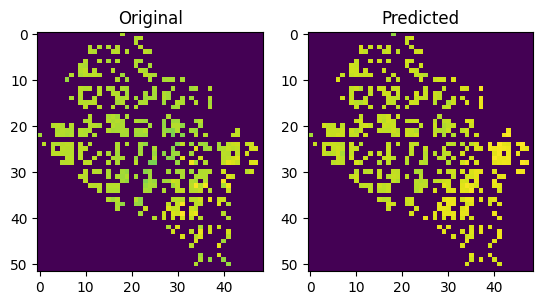

In [ ]:
plt.subplot(1, 2, 1)
plt.title('Original')
plt.imshow(ytest[90])
plt.subplot(1, 2, 2)
plt.title('Predicted')
plt.imshow(y_pred[90])
plt.show()

Raster Model

In [ ]:
from matplotlib.colors import LinearSegmentedColormap

In [ ]:
def draw_map(x,y,z, title="",subtitle="",units=""):
  mpl.style.use('default')
  # Estos colores cambiarlos según el tipo de estudio
  # Agua preferiblemente en azules
  # Vegetación en verdes
  colors = [(0, 0, 1), (0, 0.7, 0),(0, 1, 0),(0.9,1,0),(1,0.7,0),(1, 0.5, 0),(1, 0, 0) ]
  cmap_name = 'my_list'
  cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=100)
  marker_size = 5
  plt.scatter(x, y, marker_size, z, cmap=cm)
  plt.axis('equal')
  plt.title(title+"\n"+subtitle)
  cbar = plt.colorbar()
  cbar.set_label(units, labelpad=+1)
  plt.xticks([])
  plt.yticks([])
  plt.show()

In [ ]:
def get_images(df,max_lat,min_lat,max_lon,min_lon):
  rows = int(np.ceil((max_lat - min_lat) / 4950)) + 1
  cols = int(np.ceil((max_lon - min_lon) / 4950)) + 1
  matrix_b1 = np.zeros((cols, rows))
  matrix_b2 = np.zeros((cols, rows))
  matrix_b3 = np.zeros((cols, rows))
  matrix_b4 = np.zeros((cols, rows))
  matrix_b5 = np.zeros((cols, rows))
  matrix_b6 = np.zeros((cols, rows))
  matrix_b7 = np.zeros((cols, rows))
  matrix_irradiance = np.zeros((cols, rows))

  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_lat) / 4950))
      lon_index = int(np.floor((max_lon-row['lon']) / 4950))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        matrix_b1[lon_index, lat_index] = row['band1']
        matrix_b2[lon_index, lat_index] = row['band2']
        matrix_b3[lon_index, lat_index] = row['band3']
        matrix_b4[lon_index, lat_index] = row['band4']
        matrix_b5[lon_index, lat_index] = row['band5']
        matrix_b6[lon_index, lat_index] = row['band6']
        matrix_b7[lon_index, lat_index] = row['band7']
        matrix_irradiance[lon_index, lat_index] = row['irradiance']

  satelital_image = np.stack((matrix_b1, matrix_b2, matrix_b3, matrix_b4, matrix_b5, matrix_b6, matrix_b7), axis=-1)
  return satelital_image,matrix_irradiance

def get_dataframe(df,matrix,max_lat,min_lat,max_lon,min_lon):
  rows = int(np.ceil((max_lat - min_lat) / 4950)) + 1
  cols = int(np.ceil((max_lon - min_lon) / 4950)) + 1
  lat=[]
  lon=[]
  irradiance=[]
  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_lat) / 4950))
      lon_index = int(np.floor((max_lon-row['lon']) / 4950))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        lat.append(row['lat'])
        lon.append(row['lon'])
        irradiance.append(matrix[lon_index, lat_index])

  df_result=pd.DataFrame({'latitude':lat,'longitude':lon,'irradiance':irradiance})
  return df_result

In [ ]:
dff=pd.read_csv('/content/drive/MyDrive/investigacion/csv/landsat_model.csv')
dff.rename(columns={'latitude': 'lat',
                    'longitude': 'lon',
                    'value':'irradiance'}, inplace=True)
dff.head()

,lat,lon,band1,band2,band3,band4,band5,band6,band7,irradiance
0,-8789850.0,184950.0,0.105113,0.082716,0.052756,0.315520,0.132641,296.178607,0.044586,203.4
1,-8784900.0,174600.0,0.104840,0.085732,0.053527,0.271463,0.090247,295.969710,0.027292,198.3
2,-8775000.0,164700.0,0.103468,0.079147,0.048932,0.248619,0.078593,296.842689,0.022098,203.1
3,-8775000.0,169650.0,0.108849,0.090665,0.055715,0.338889,0.128227,296.123927,0.039798,199.1
4,-8775000.0,174600.0,0.096526,0.071028,0.042247,0.194788,0.054468,294.407491,0.017712,196.3


In [ ]:
min_lat=df["lat"].min()
max_lat=df["lat"].max()
min_lon=df["lon"].min()
max_lon=df["lon"].max()
print(min_lat,max_lat,min_lon,max_lon)

-8789850.0 -8554950.0 45000.0 294750.0


In [ ]:
dfnar=pd.read_csv("/content/drive/MyDrive/investigacion/csv/gridNarinio.csv")
dfnar.head()

,Unnamed: 0,lat,lon
0,0,-8.623484e+06,45000.0
1,1,-8.622961e+06,45000.0
2,2,-8.622438e+06,45000.0
3,3,-8.621915e+06,45000.0
4,4,-8.621392e+06,45000.0


In [ ]:
Xi =dfnar.loc[:,"lat"].to_numpy()
Yi =dfnar.loc[:,"lon"].to_numpy()

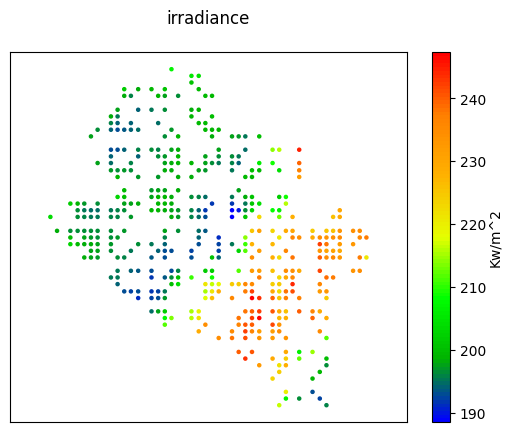

In [ ]:
draw_map(dff.lat,dff.lon,dff.irradiance,"irradiance","","Kw/m^2")

Draw prediction

In [ ]:
yp=y_pred[90]
yp=yp.reshape(yp.shape[0],yp.shape[1])
yp=scaler.inverse_transform(yp.reshape(-1, 1)).reshape(yp.shape)
yp.shape

(52, 49)

In [ ]:
df_result=get_dataframe(dff,yp,max_lat,min_lat,max_lon,min_lon)

df_result.head()

,latitude,longitude,irradiance
0,-8789850.0,184950.0,189.621384
1,-8784900.0,174600.0,200.379303
2,-8775000.0,164700.0,201.845413
3,-8775000.0,169650.0,202.449814
4,-8775000.0,174600.0,201.325012


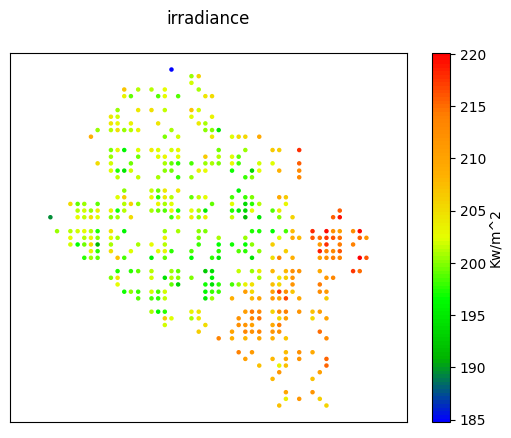

In [ ]:
draw_map(df_result.latitude,df_result.longitude,df_result.irradiance,"irradiance","","Kw/m^2")

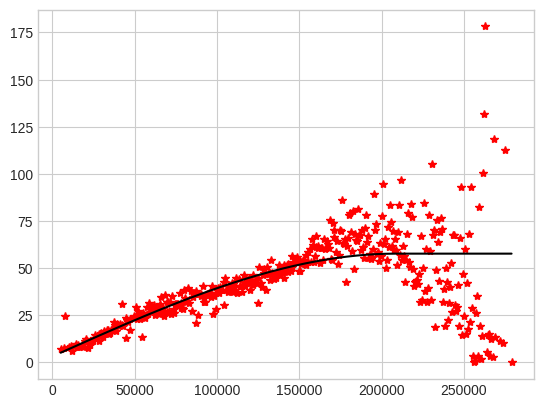

In [ ]:
mpl.style.use('seaborn-v0_8-whitegrid')
OK2 = OrdinaryKriging(df_result.latitude,df_result.longitude,df_result.irradiance, variogram_model='spherical', nlags=450,
                    enable_plotting=True,
                    coordinates_type='euclidean')

aqui

In [ ]:
irradiance2, ss2 = OK2.execute('points', Xi, Yi) # z la radiacion y ss la varianza

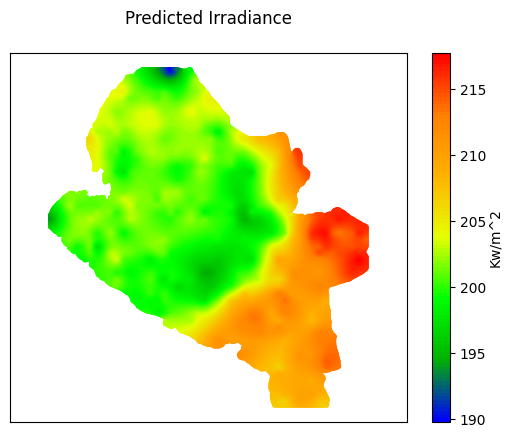

In [ ]:
draw_map(Xi,Yi,irradiance2,"Predicted Irradiance","","Kw/m^2")

 Convert to image

In [ ]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

In [ ]:
def getcolormap(zrk):
  #Cambiar por los colores del estudio realizado
  colors = [(0, 0, 1), (0, 0.7, 0),(0, 1, 0),(0.9,1,0),(1,0.7,0),(1, 0.5, 0),(1, 0, 0) ]
  cmap_name = 'my_list'
  cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=100)
  norm = Normalize(vmin=irradiance_min,vmax=irradiance_max)
  return cm(norm(zrk))

In [ ]:
ymin=Yi.min()
ymax=Yi.max()
xmin=Xi.min()
xmax=Xi.max()

irradiance_min=min(irradiance2)
irradiance_max=max(irradiance2)
resolution=40

In [ ]:
mycolors=getcolormap(irradiance2)
mycolors.shape

(109747, 4)

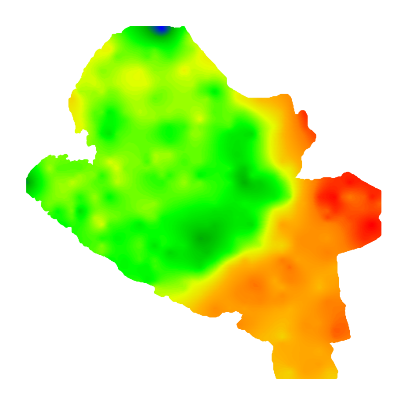

In [ ]:
#figsize
plt.figure(figsize=(5,5))
#axis none
plt.axis('off')
plt.scatter(Xi,Yi,1,color=mycolors)

Generate Raster

In [ ]:
x_u=np.unique(Xi)
y_u=np.unique(Yi)

x_u=np.sort(x_u)
y_u=np.sort(y_u)
dif_x=np.diff(x_u)
dif_y=np.diff(y_u)

min_dif_x=np.min(dif_x)
min_dif_y=np.min(dif_y)

print(min_dif_x,min_dif_y)

523.1625835187733 556.2360801781178


In [ ]:
Xi.shape, Yi.shape

((109747,), (109747,))

In [ ]:
dfnar['red']=mycolors[:,0]
dfnar['green']=mycolors[:,1]
dfnar['blue']=mycolors[:,2]
dfnar['alpha']=mycolors[:,3]

In [ ]:
def get_images(df,max_x,min_x,max_y,min_y,min_dif_x,min_dif_y):
  rows = int(np.ceil((max_y - min_y) / min_dif_y)) + 1
  cols = int(np.ceil((max_x - min_x) / min_dif_x)) + 1
  matrix_b1 = np.zeros((cols, rows))
  matrix_b2 = np.zeros((cols, rows))
  matrix_b3 = np.zeros((cols, rows))
  matrix_b4 = np.zeros((cols, rows))


  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_x) / min_dif_x))
      lon_index = int(np.floor((max_y-row['lon']) / min_dif_y))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        matrix_b1[lon_index, lat_index] = row['red']
        matrix_b2[lon_index, lat_index] = row['green']
        matrix_b3[lon_index, lat_index] = row['blue']
        matrix_b4[lon_index, lat_index] = 0.6


  raster = np.stack((matrix_b1, matrix_b2, matrix_b3, matrix_b4), axis=-1)

  return (raster*255).astype(np.uint8)

In [ ]:
raster_narino=get_images(dfnar,xmax,xmin,ymax,ymin,min_dif_x,min_dif_y)
raster_narino[:,:,0:3].shape

(451, 451, 3)

In [ ]:
#green chanel
raster_narino[:,:,0:3].min(),raster_narino[:,:,0:3].max()

(np.uint8(0), np.uint8(255))

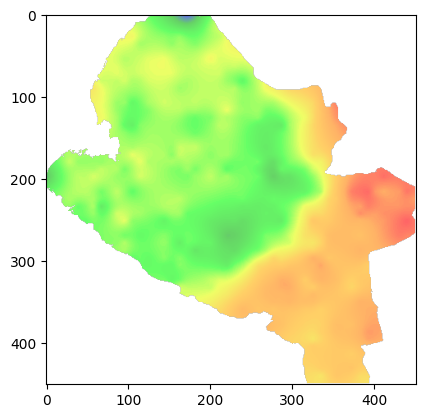

In [ ]:
plt.imshow(raster_narino[:,:,:])

In [ ]:
raster_narino.shape

(451, 451, 4)

In [ ]:
#save raster_narino
#save raster_narino
from skimage import io
import numpy as np
path_image='/content/drive/MyDrive/investigacion/3ddespues/landsatimg'

# Convert raster_narino to uint8 before saving
raster_narino_uint8 = raster_narino.astype(np.uint8)

io.imsave(path_image+'raster_narino_forecasting.png', raster_narino_uint8)


aqui

In [ ]:
#!/usr/bin/env python
from skimage import io
from osgeo import gdal
from osgeo import osr
import numpy as np
import os, sys

#  Initialize the Image Size
def saveGeotiffImage(raster,name):
  image_size = raster.shape


  # set geotransform
  nx = image_size[0]
  ny = image_size[1]


  # set geotransform
  nx = image_size[0]
  ny = image_size[1]

  xres = (xmax - xmin) / float(nx)
  yres = (ymax - ymin) / float(ny)
  geotransform = (xmin, xres, 0, ymax, 0, -yres)

  # create the 3-band raster file
  dst_ds = gdal.GetDriverByName('GTiff').Create(path_image+'4B3857'+name+'.tif', ny, nx, 4, gdal.GDT_Byte)

  dst_ds.SetGeoTransform(geotransform)    # specify coords
  srs = osr.SpatialReference()            # establish encoding
  srs.ImportFromEPSG(3857)                # WGS84 lat/long
  dst_ds.SetProjection(srs.ExportToWkt()) # export coords to file
  dst_ds.GetRasterBand(1).WriteArray(raster[:,:,0])   # write r-band to the raster
  dst_ds.GetRasterBand(2).WriteArray(raster[:,:,1])   # write g-band to the raster
  dst_ds.GetRasterBand(3).WriteArray(raster[:,:,2])   # write b-band to the raster
  dst_ds.GetRasterBand(4).WriteArray(raster[:,:,3])   # write b-band to the raster
  dst_ds.FlushCache()                     # write to disk
  return dst_ds

In [ ]:
dst_ds=saveGeotiffImage(raster_narino_uint8,"Forecasting")

/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(
